In [ ]:
#pip install typing
#pip install timm
#pip install hiera-transformer
#pip install transformers
#pip install numpy==1.23
#pip install --upgrade Pillow
#pip install datasets


In [7]:
from astropy.io import fits
import drms
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os
import requests
from torch.utils.data import Dataset, DataLoader, random_split
import re
import torch
import cv2
from datetime import datetime, timedelta
import sunpy.visualization.colormaps as cm
import sunpy.map
from astropy.visualization import wcsaxes
from transformers import HieraConfig, HieraModel
import torchvision.transforms as transforms

import importlib.util
import importlib.metadata
from packaging import version

import inspect

from typing import List, Tuple, Callable, Optional, Union, Type
import torch.nn as nn
from functools import partial
from timm.models.layers import DropPath, Mlp
from torch.optim import Adam
import math
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## Plot the solar images

In [14]:
map_name = file.split("[")[2].split("]")[0]
print(map_name)

171


[2010-05-25T00:00:02Z][131]aia_lev1_euv_12s.fits
sdoaia131


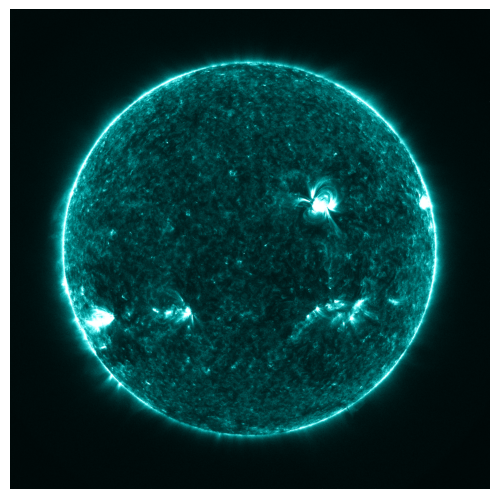

[2010-05-25T00:00:02Z][171]aia_lev1_euv_12s.fits
sdoaia171


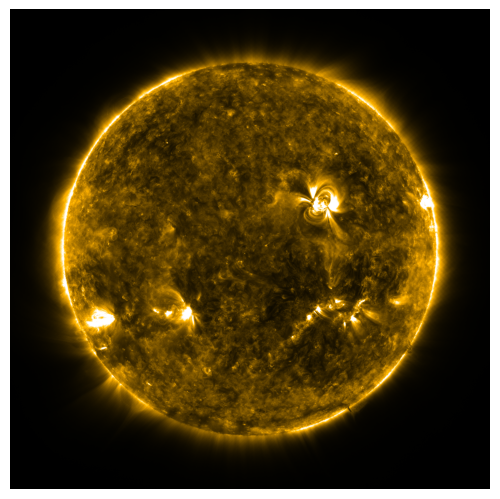

[2010-05-25T00:00:02Z][193]aia_lev1_euv_12s.fits
sdoaia193


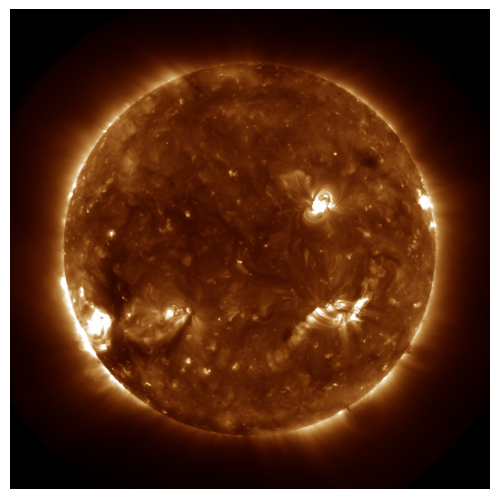

[2010-05-25T00:00:02Z][211]aia_lev1_euv_12s.fits
sdoaia211


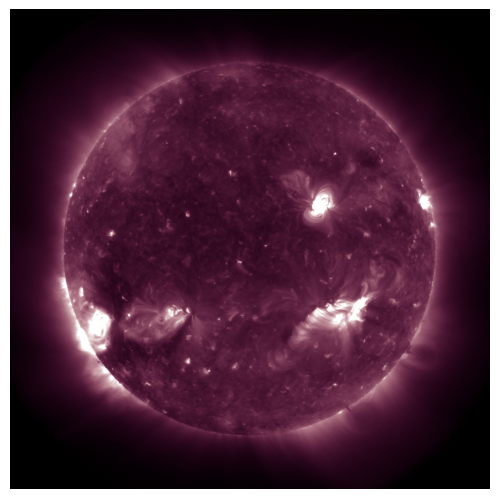

[2010-05-25T00:00:02Z][304]aia_lev1_euv_12s.fits
sdoaia304


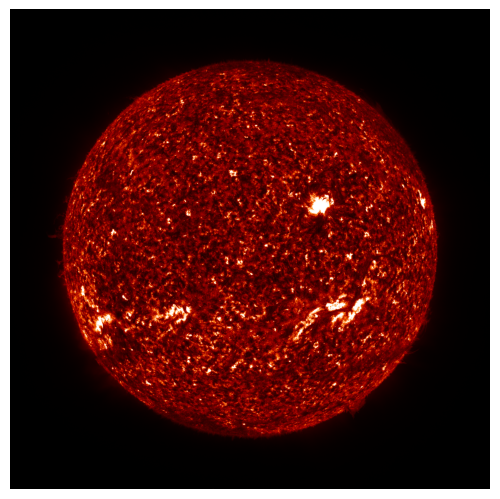

[2010-05-25T00:00:02Z][335]aia_lev1_euv_12s.fits
sdoaia335


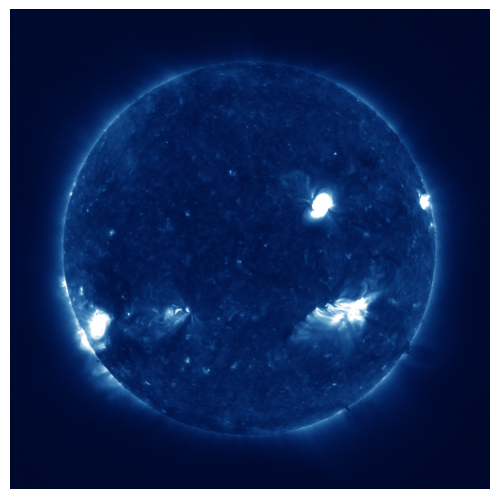

[2010-05-25T00:00:02Z][94]aia_lev1_euv_12s.fits
sdoaia94


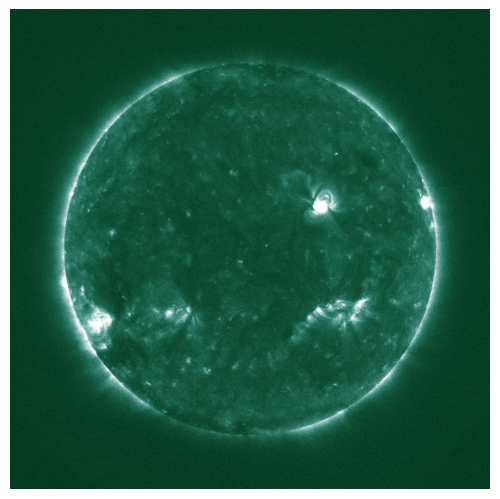

[2010-05-25T00:00:14Z][1600]aia_lev1_uv_24s.fits
sdoaia1600


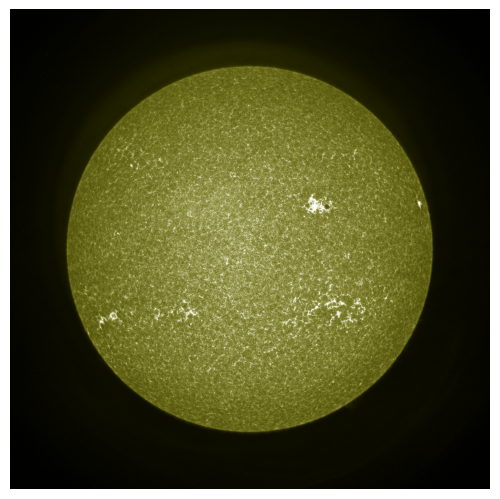

[2010-05-25T00:00:14Z][1700]aia_lev1_uv_24s.fits
sdoaia1700


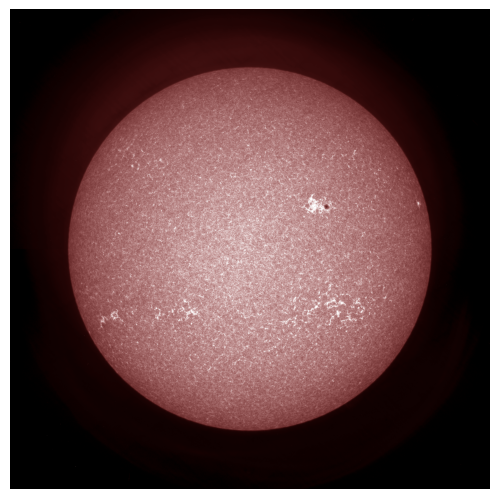

In [26]:
import os
import sunpy.map
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

folder_path = "/home/gpatane/Dataset/AIA_folder"

fits_files = os.listdir(folder_path)
fits_files.sort()
fits_list = fits_files[101:110]
for i, file in enumerate(fits_list):
    #if file.endswith("[M]hmi_M_720s.fits"):
    if file.endswith(".fits"):
        file_path = os.path.join(folder_path, file)

        data, header = fits.getdata(file_path, header=True)
        #data = np.nan_to_num(data, nan=0)
        print(file)
        header['cunit1'] = 'arcsec'
        header['cunit2'] = 'arcsec'
        #try:
        header_string = header.tostring()
        header = fits.Header.fromstring(header_string)
        # for key, value in header.items():
        #     if key == 'RSUN_OBS':
        #         if isinstance(value, str):
        #             print(f"{key}: {value}")
        #         else:
        #             print(f"{key}: {value}")


        # try:
        #     updated_map = sunpy.map.Map(data, header)
        # except Exception as e:
        #     print(f"Error creating SunPy map for file {file}: {e}")
        #     continue  
        # updated_map = sunpy.map.Map(data, header)
        # #updated_map.peek()

        # fig = plt.figure()
        # ax = fig.add_subplot(111, projection=updated_map.wcs)
        # updated_map.plot(axes=ax)
        # #plt.title(file)

        # ax.axis('off')
        # plt.show()
        fig = plt.figure(frameon=False)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)
        map_name = "sdoaia" + str(file.split("[")[2].split("]")[0])
        #print(map_name)
        ax.imshow(data, cmap=map_name, vmax=np.percentile(data, 99.5), vmin=np.percentile(data, 2.5))
        plt.show()
        


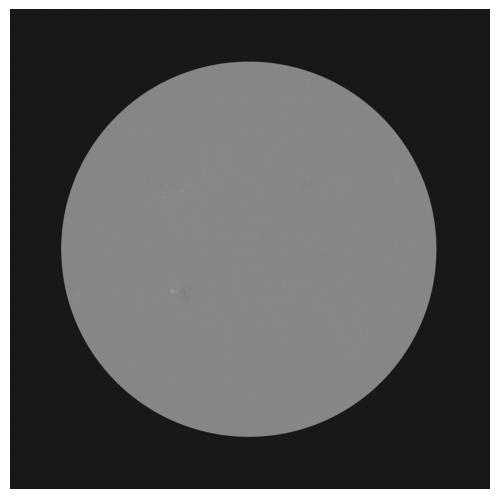

In [45]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# open a single file
file_path = "/home/gpatane/Dataset/Magnetogram/hmi.M_720s[2010.05.25_00:00:00_TAI][1].fits"
data = fits.getdata(file_path)
data = np.nan_to_num(data, nan=-5000)

original_shape = data.shape

# --- riduci l'immagine al centro (83%) ---
scale = 0.83
reduced = zoom(data, scale)  # resize mantenendo proporzioni

# --- calcola padding per tornare alla dimensione originale ---
pad_y = (original_shape[0] - reduced.shape[0]) // 2
pad_x = (original_shape[1] - reduced.shape[1]) // 2

# padding simmetrico
padded = np.pad(
    reduced,
    ((pad_y, original_shape[0] - reduced.shape[0] - pad_y),
     (pad_x, original_shape[1] - reduced.shape[1] - pad_x)),
    mode='constant',
    constant_values=-5000  # stesso valore usato per riempire i NaN
)

# --- mostra il risultato ---
fig = plt.figure(frameon=False)
ax = plt.Axes(fig, [0, 0, 1, 1])
ax.set_axis_off()
fig.add_axes(ax)
ax.imshow(padded, cmap="gray")
plt.show()


In [12]:
folder_path = "Download"

fits_files = os.listdir(folder_path)
fits_files.sort()
fits_list = fits_files[:10]
for i, file in enumerate(fits_list):
    
    if file.endswith(".fits"):
        file_path = os.path.join(folder_path, file)

        data, header = fits.getdata(file_path, header=True)
        break
(header)
        

XTENSION= 'IMAGE   '           / binary table extension                         
BITPIX  =                  -32 / data type of original image                    
NAXIS   =                    2 / dimension of original image                    
NAXIS1  =                 4096 / length of original image axis                  
NAXIS2  =                 4096 / length of original image axis                  
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
BLANK   =               -32768                                                  
CHECKSUM= 'PeAoQd6mPdAmPd3m'   / HDU checksum updated 2010-11-08T03:19:29       
DATASUM = '2464728956'         / data unit checksum updated 2010-11-08T03:19:29 
                                                                                
                                                                                

In [16]:
unique_array, index_array = np.unique(data, return_index=True)

plt.plot(index_array, unique_array, marker='*')  # marker='o' aggiunge un punto a ogni posizione
plt.title("Valori unici con i loro indici")
plt.xlabel("Indice")
plt.ylabel("Valore Unico")
plt.show()


unique_array, index_array = np.unique(data, return_index=True)
plt.scatter(unique_array,index_array)
plt.title("Grafico a linee di un array 1D")
plt.xlabel("Indice")
plt.ylabel("Valore")
plt.show()

## Lets create the Dataset...

In [3]:
def load_fits_file(file_path):
    file = os.path.basename(file_path)
    if file.endswith(".fits"):
        image_data = fits.getdata(file_path)
    return image_data

def organize_images_by_name(folder_path):
    dataset = {}

    for file in os.listdir(folder_path):
        if file.endswith(".fits"):
            if file not in dataset:
                dataset[file] = {}
                file_path = os.path.join(folder_path, file) 
            dataset[file] = file_path
    
    return dataset

def organize_images_by_date(folder_path, acquisition_times):
    """
    Organizzo le immagini per time step, creando un dataset in cui
    ogni step contiene tutte le immagini acquisite in quella data.
    """
    dataset = {}

    for file in os.listdir(folder_path):
        if file.endswith(".fits"):
            timestamp = re.findall(r'\[(.*?)\]', file)[0]
            acquisition_type = re.findall(r'\[(.*?)\]', file)[1]  
            timestamp_date = timestamp.split('T')[0]
            if acquisition_type in acquisition_times:
                if timestamp_date not in dataset:
                    dataset[timestamp_date] = {}
                    file_path = os.path.join(folder_path, file) 
                dataset[timestamp_date][acquisition_type] = file_path
    
    return dataset

acquisition_times = {
    'M': 12,        # ogni 12 minuti
    'Ic': 12,       # ogni 12 minuti
    '1600': 24,     # ogni 24 secondi
    '1700': 24,     # ogni 24 secondi
    '131': 12,      # ogni 12 secondi
    '160': 12,      # ogni 12 secondi
    '170': 12,      # ogni 12 secondi
    '171': 12,      # ogni 12 secondi
    '193': 12,      # ogni 12 secondi
    '211': 12,      # ogni 12 secondi
    '304': 12,      # ogni 12 secondi
    '335': 12,      # ogni 12 secondi
    '94': 12,       # ogni 12 secondi
}

folder_path = "Download"
dataset = organize_images_by_name(folder_path)
timestamps = sorted(dataset.keys()) 
print(timestamps[10])
print(dataset[timestamps[10]])


[2010-10-07T00:00:14Z][1700]aia_lev1_uv_24s.fits
Download/[2010-10-07T00:00:14Z][1700]aia_lev1_uv_24s.fits


In [4]:
class SolarImageDataset(Dataset):
    def __init__(self, dataset, acquisition_times, transform=None):
        """
        dataset: il dataset organizzato in time-step
        acquisition_times: dizionario dei tempi di acquisizione per ciascuna modalità
        transform: eventuali trasformazioni da applicare ai dati
        """
        self.dataset = dataset
        self.timestamps = sorted(dataset.keys())  
        self.acquisition_times = acquisition_times
        self.transform = transform

    def __len__(self):
        return len(self.timestamps)

    def __getitem__(self, idx):
        timestamp = self.timestamps[idx]
        image_paths = self.dataset[timestamp]
        
        images = {key: load_fits_file(path) for key, path in image_paths.items()}

        img_tensor = {key: torch.tensor(img) for key, img in images.items()}

        if self.transform:
            img_tensor = self.transform(img_tensor)

        return img_tensor, timestamp
    
    
    
class SolarImageDataset_patch(Dataset):
    def __init__(self, dataset, transform=None):
        """
        dataset: il dataset organizzato in time-step
        transform: eventuali trasformazioni da applicare ai dati
        """
        self.dataset = dataset
        self.timestamps = sorted(dataset.keys()) 
        self.transform = transform

    def __len__(self):
        return len(self.timestamps)

    def __getitem__(self, idx):
        timestamp = self.timestamps[idx]
        image_paths = self.dataset[timestamp]
        
        images = load_fits_file(image_paths)  

        img_tensor = torch.tensor(images).unsqueeze(0) 

        if self.transform:
            img_tensor = self.transform(img_tensor)

        return img_tensor, timestamp

In [5]:
'''transform = transforms.Compose([
    transforms.Resize((512, 512)), 
    transforms.ConvertImageDtype(torch.float32),  # Converte in float32
])'''

#data = SolarImageDataset_patch(dataset, transform=transform)
data = SolarImageDataset_patch(dataset)

train_size = int(0.8 * len(data))
test_size = len(data) - train_size
train_dataset, test_dataset = random_split(data, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

for batch_images, timestamps in train_loader:
    print((batch_images).shape) 
    print(timestamps)            
    break

batch_images_2, timestamps_2 = next(iter(train_loader))
print((batch_images_2).shape)
print(timestamps_2)  

torch.Size([1, 1, 4096, 4096])
('[2012-08-12T00:00:01Z][94]aia_lev1_euv_12s.fits',)
torch.Size([1, 1, 4096, 4096])
('[2019-10-20T00:00:11Z][131]aia_lev1_euv_12s.fits',)


In [10]:
pip install numba

     |████████████████████████████████| 3.7 MB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 43.6 MB 42.6 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [11]:
from numba import cuda
cuda.select_device(0) # choosing second GPU 
cuda.close()

In [6]:
from transformers import AutoConfig, HieraForPreTraining

config = AutoConfig.from_pretrained("facebook/hiera-base-plus-224-mae-hf")

config.image_size = [4096, 4096]  
config.num_channels = 1        
device = torch.device('cuda:0')
print(device)
model = HieraForPreTraining(config)
model.to(device)


cuda:0


HieraForPreTraining(
  (hiera): HieraModel(
    (embeddings): HieraEmbeddings(
      (patch_embeddings): HieraPatchEmbeddings(
        (projection): Conv2d(1, 112, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      )
    )
    (encoder): HieraEncoder(
      (stages): ModuleList(
        (0): HieraStage(
          (layers): ModuleList(
            (0-1): 2 x HieraLayer(
              (layernorm_before): LayerNorm((112,), eps=1e-06, elementwise_affine=True)
              (attn): HieraMaskUnitAttention(
                (qkv): Linear(in_features=112, out_features=336, bias=True)
                (proj): Linear(in_features=112, out_features=112, bias=True)
              )
              (layernorm_after): LayerNorm((112,), eps=1e-06, elementwise_affine=True)
              (mlp): HieraMlp(
                (activation_fn): GELUActivation()
                (fc1): Linear(in_features=112, out_features=448, bias=True)
                (fc2): Linear(in_features=448, out_features=112, bias=True)

In [7]:

output = model(batch_images_2.to(device))

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.48 GiB. GPU 

In [13]:
# Visualizza il valore della loss
print("Loss:", output.loss.item())

# Visualizza i logits
print("Logits shape:", output.logits.shape)
print("Logits (prime 5 righe):", output.logits[0, :5])  # Visualizza le prime 5 righe dei logits per evitare troppi dati

# Visualizza la maschera booleana di posizione (per esempio, per i pixel mascherati)
print("Boolean Masked Positions:", output.bool_masked_pos)
print("Boolean Masked Positions Shape:", output.bool_masked_pos.shape)

# Visualizza gli ID di ripristino (per la ricostruzione delle posizioni originali)
print("IDs Restore:", output.ids_restore)
print("IDs Restore Shape:", output.ids_restore.shape)

# Verifica se ci sono stati nascosti o attenzioni e li visualizza se non sono None
if output.hidden_states is not None:
    print("Hidden States Shape:", output.hidden_states.shape)
else:
    print("No Hidden States")

if output.attentions is not None:
    print("Attentions Shape:", output.attentions.shape)
else:
    print("No Attentions")


Loss: 0.20698848366737366
Logits shape: torch.Size([1, 1024, 256])
Logits (prime 5 righe): tensor([[-0.0329, -0.2405, -0.0610,  ...,  0.7150,  0.0547,  0.2428],
        [-0.0696, -0.1764, -0.2909,  ...,  0.6564,  0.0411,  0.2756],
        [-0.0824, -0.3049, -0.2558,  ...,  0.0540, -0.1257, -0.4805],
        [ 0.0038, -0.3186, -0.2512,  ...,  0.0898, -0.0641, -0.5440],
        [-0.0563, -0.3062, -0.2577,  ...,  0.1162, -0.0955, -0.5365]],
       grad_fn=<SliceBackward0>)
Boolean Masked Positions: tensor([[ True,  True, False,  ...,  True, False, False]])
Boolean Masked Positions Shape: torch.Size([1, 1024])
IDs Restore: tensor([[ 53, 130, 203, 223, 243,  81, 128, 142, 117,  42, 219,  43, 179, 202,
         214, 101, 229, 197, 175,  85,  20, 149,  56, 137, 105, 123,  37, 145,
         166, 226, 180,  74, 100,  17, 246,  62,  46,  39,  97,  58, 216,  15,
          63,  90,  31, 131,   5, 249, 186, 200, 133, 207, 116,  73,  75, 122,
         164, 109,  10,  80, 242, 227, 125, 195,   2, 174

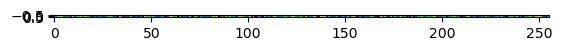

In [14]:
plt.imshow(output.ids_restore)